# Assignment 1: Unsupervised Learning Methods
### Clustering Patient Data: A Comparative Analysis

### Authors:
- Michael George Nabih Lotfy Eskander
- David Hidalgo Fàbregas
- Miriam Iturralde Aguiló
- Pablo Longán Gasol
- Joao Constantino Muianga

### Libraries:

In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
import copy

# 1. Data Exploration

## 1.1 Loading & Shape Check

In [249]:
columns = [
    "age", "sex", "cp", "trestbps",
    "chol", "fbs", "restecg",
    "thalach", "exang",
    "oldpeak", "slope",
    "ca", "thal", "target"
]

df = pd.read_csv(
    "../data/01_raw/processed.cleveland.data",
    sep=",",          # dataset separator
    header=None,      # indicates that there are NO headers
    names=columns,     # asigns column names
    na_values = "?"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


We can see that the missing values are marked with a question mark, so we will remove them. We also need to convert the float variables back to their original data type of integer/categorical.

### Missing Values:

In [250]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [251]:
df = df.fillna(df.median())
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Data Types:

In [252]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [253]:
for col in df.select_dtypes(include='number').columns:
    if (df[col] % 1 == 0).all():    # Check if all values from a column are actually integers
        df[col] = df[col].astype('Int64')

cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for i in cat_features:
    df[i] = df[i].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    Int64   
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    Int64   
 4   chol      303 non-null    Int64   
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    Int64   
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    Int64   
 12  thal      303 non-null    category
 13  target    303 non-null    Int64   
dtypes: Int64(6), category(7), float64(1)
memory usage: 20.9 KB


### Data Shape:

In [254]:
print(df.shape) # dataframe dimension

(303, 14)


## 1.2 Distributions

In [255]:
df.describe()

,age,trestbps,chol,thalach,oldpeak,ca,target
count,303.0,303.0,303.0,303.0,303.000000,303.0,303.0
mean,54.438944,131.689769,246.693069,149.607261,1.039604,0.663366,0.937294
std,9.038662,17.599748,51.776918,22.875003,1.161075,0.934375,1.228536
min,29.0,94.0,126.0,71.0,0.000000,0.0,0.0
25%,48.0,120.0,211.0,133.5,0.000000,0.0,0.0
50%,56.0,130.0,241.0,153.0,0.800000,0.0,0.0
75%,61.0,140.0,275.0,166.0,1.600000,1.0,2.0
max,77.0,200.0,564.0,202.0,6.200000,3.0,4.0


### Target distribution

We have four types of diagnosis in the dataset:

In [256]:
print(df['target'].unique())

<IntegerArray>
[0, 2, 1, 3, 4]
Length: 5, dtype: Int64


Now, let's see how many samples we have for each type of diagnosis.

In [257]:
print(df.groupby('target').size())

target
0    164
1     55
2     36
3     35
4     13
dtype: int64


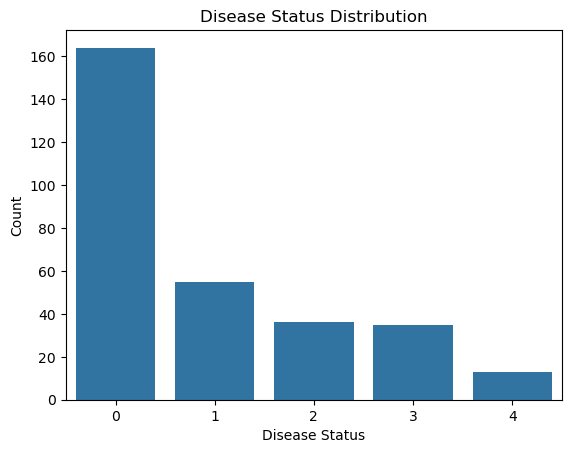

In [258]:
#classes bar plot (Balanced number of classes)
ax = sns.countplot(x=df['target'])
ax.set_xlabel("Disease Status")
ax.set_ylabel("Count")
ax.set_title("Disease Status Distribution")
plt.show()

#### Binarize target Value

In [259]:
# Convert target to binary (0: no disease, 1: disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

### Categorical Features Distributions

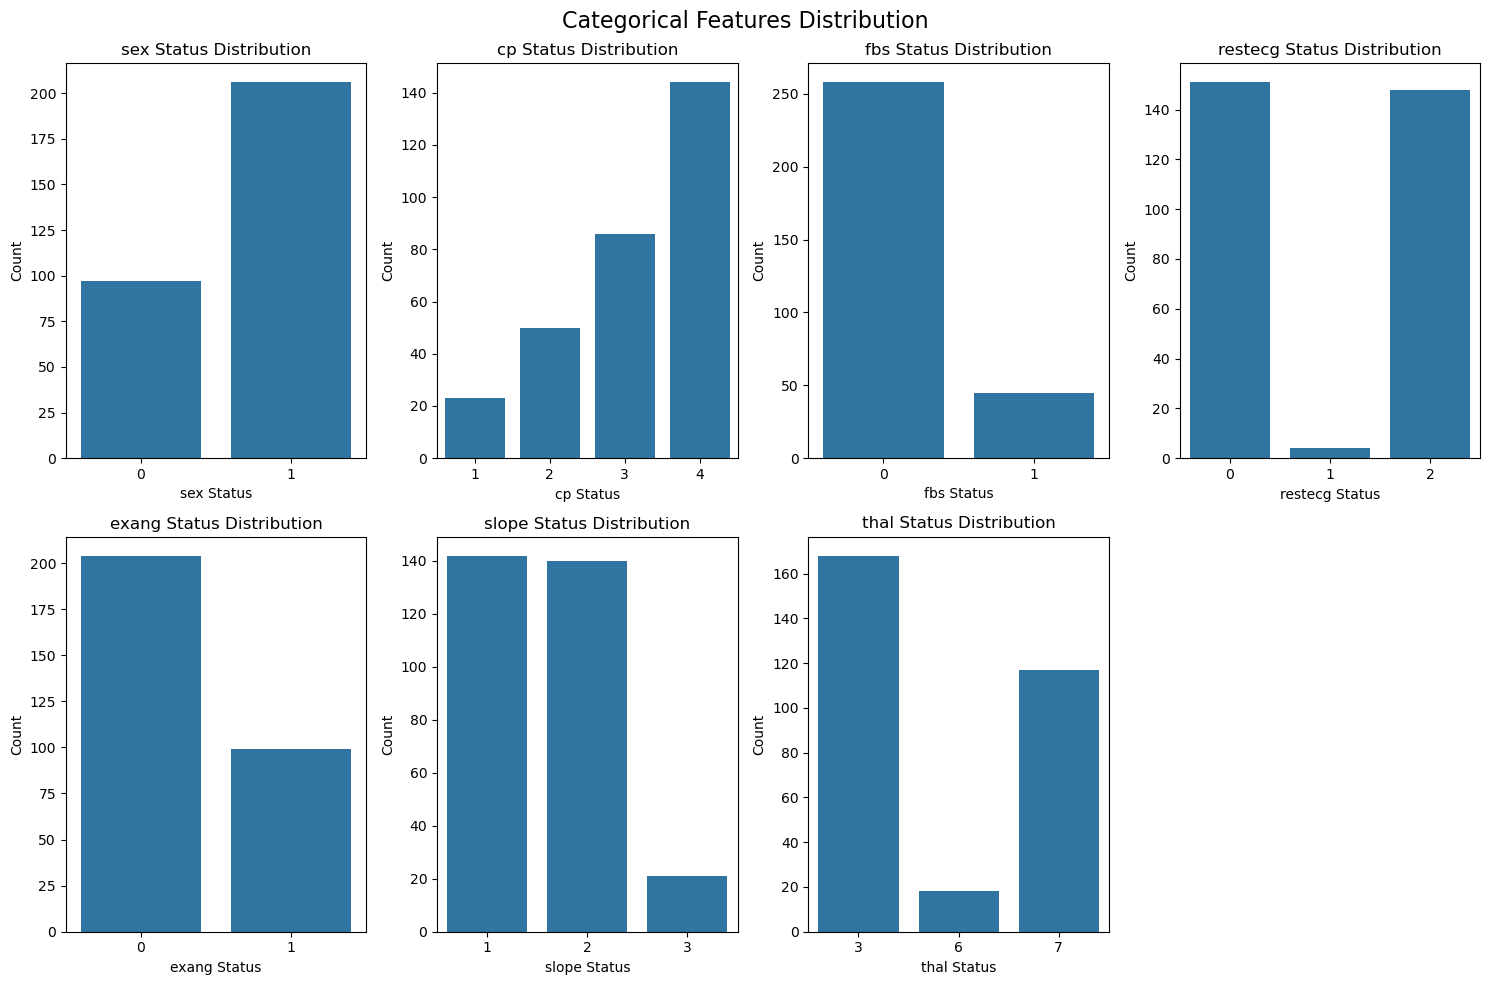

In [260]:
cols = df.select_dtypes(include='category').columns
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
ax= axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=df[col], ax=ax[i])
    ax[i].set_xlabel(f"{col} Status")
    ax[i].set_ylabel("Count")
    ax[i].set_title(f"{col} Status Distribution")

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.suptitle("Categorical Features Distribution", fontsize=16)
plt.tight_layout()
plt.show()

### Numerical Features Distributions

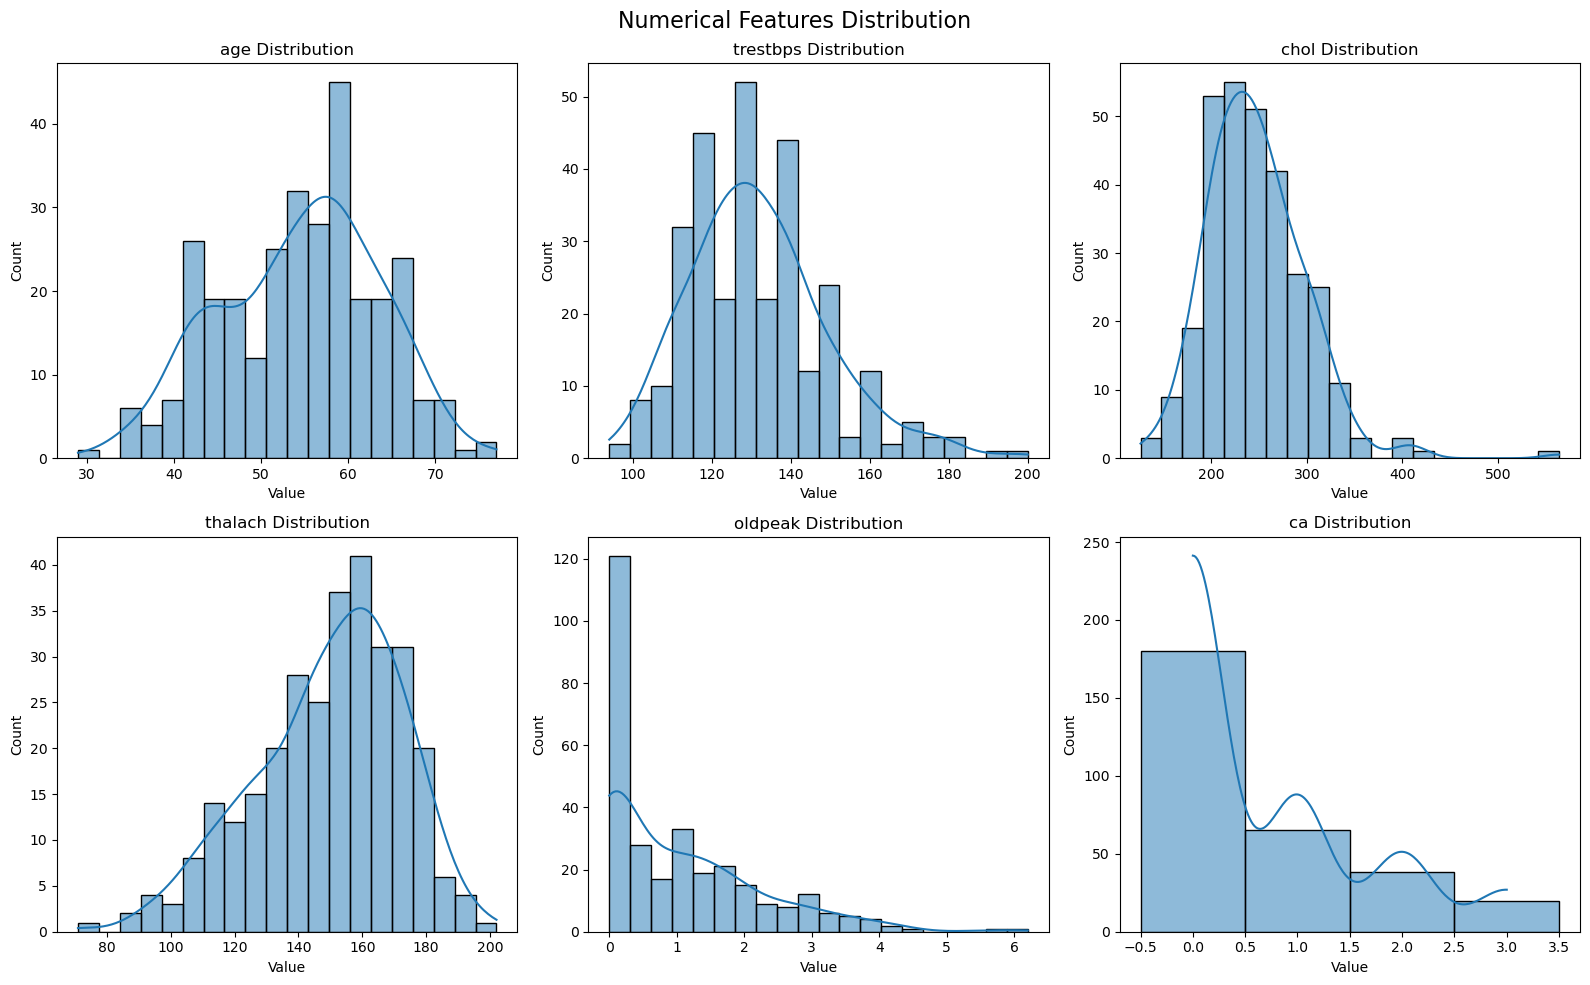

In [261]:
cols = df.select_dtypes(include="number").columns.drop('target')  # Exclude the target variable

fig, axes = plt.subplots(2, 3, figsize=(16,10))
ax = axes.flatten()

for i, col in enumerate(cols):
    if col == 'ca':  # For the 'ca' column, use a countplot instead of histplot
        sns.histplot(df[col], bins=20, kde=True, discrete=True, ax=ax[i])
    else:
        sns.histplot(df[col], bins=20, kde=True, ax=ax[i])
    ax[i].set_xlabel("Value")
    ax[i].set_ylabel("Count")
    ax[i].set_title(f"{col} Distribution")

plt.suptitle("Numerical Features Distribution", fontsize=16)
plt.tight_layout()
plt.show()

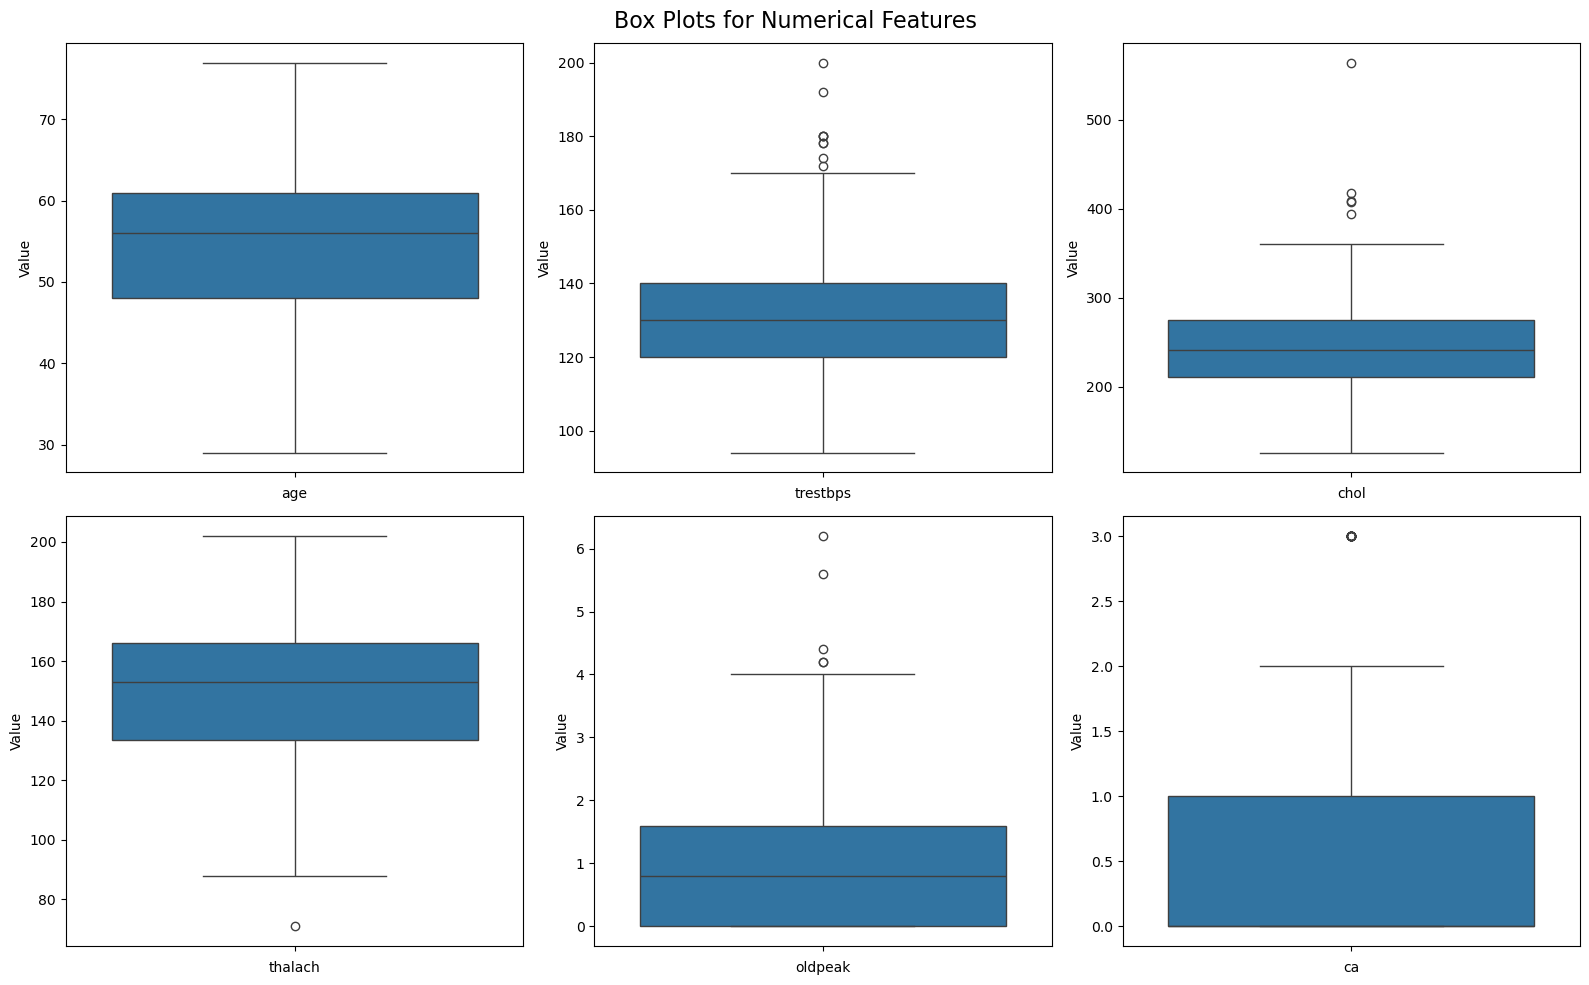

In [262]:
cols = df.select_dtypes(include="number").columns.drop('target')  # Exclude the target variable
fig, axes = plt.subplots(2, 3, figsize=(16,10))
ax = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=ax[i])
    ax[i].set_xlabel(f"{col}")
    ax[i].set_ylabel('Value')

plt.suptitle("Box Plots for Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## 1.3 Correlation Analysis

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


Text(0.5, 0.98, 'Scatter-matrix for each input variable')

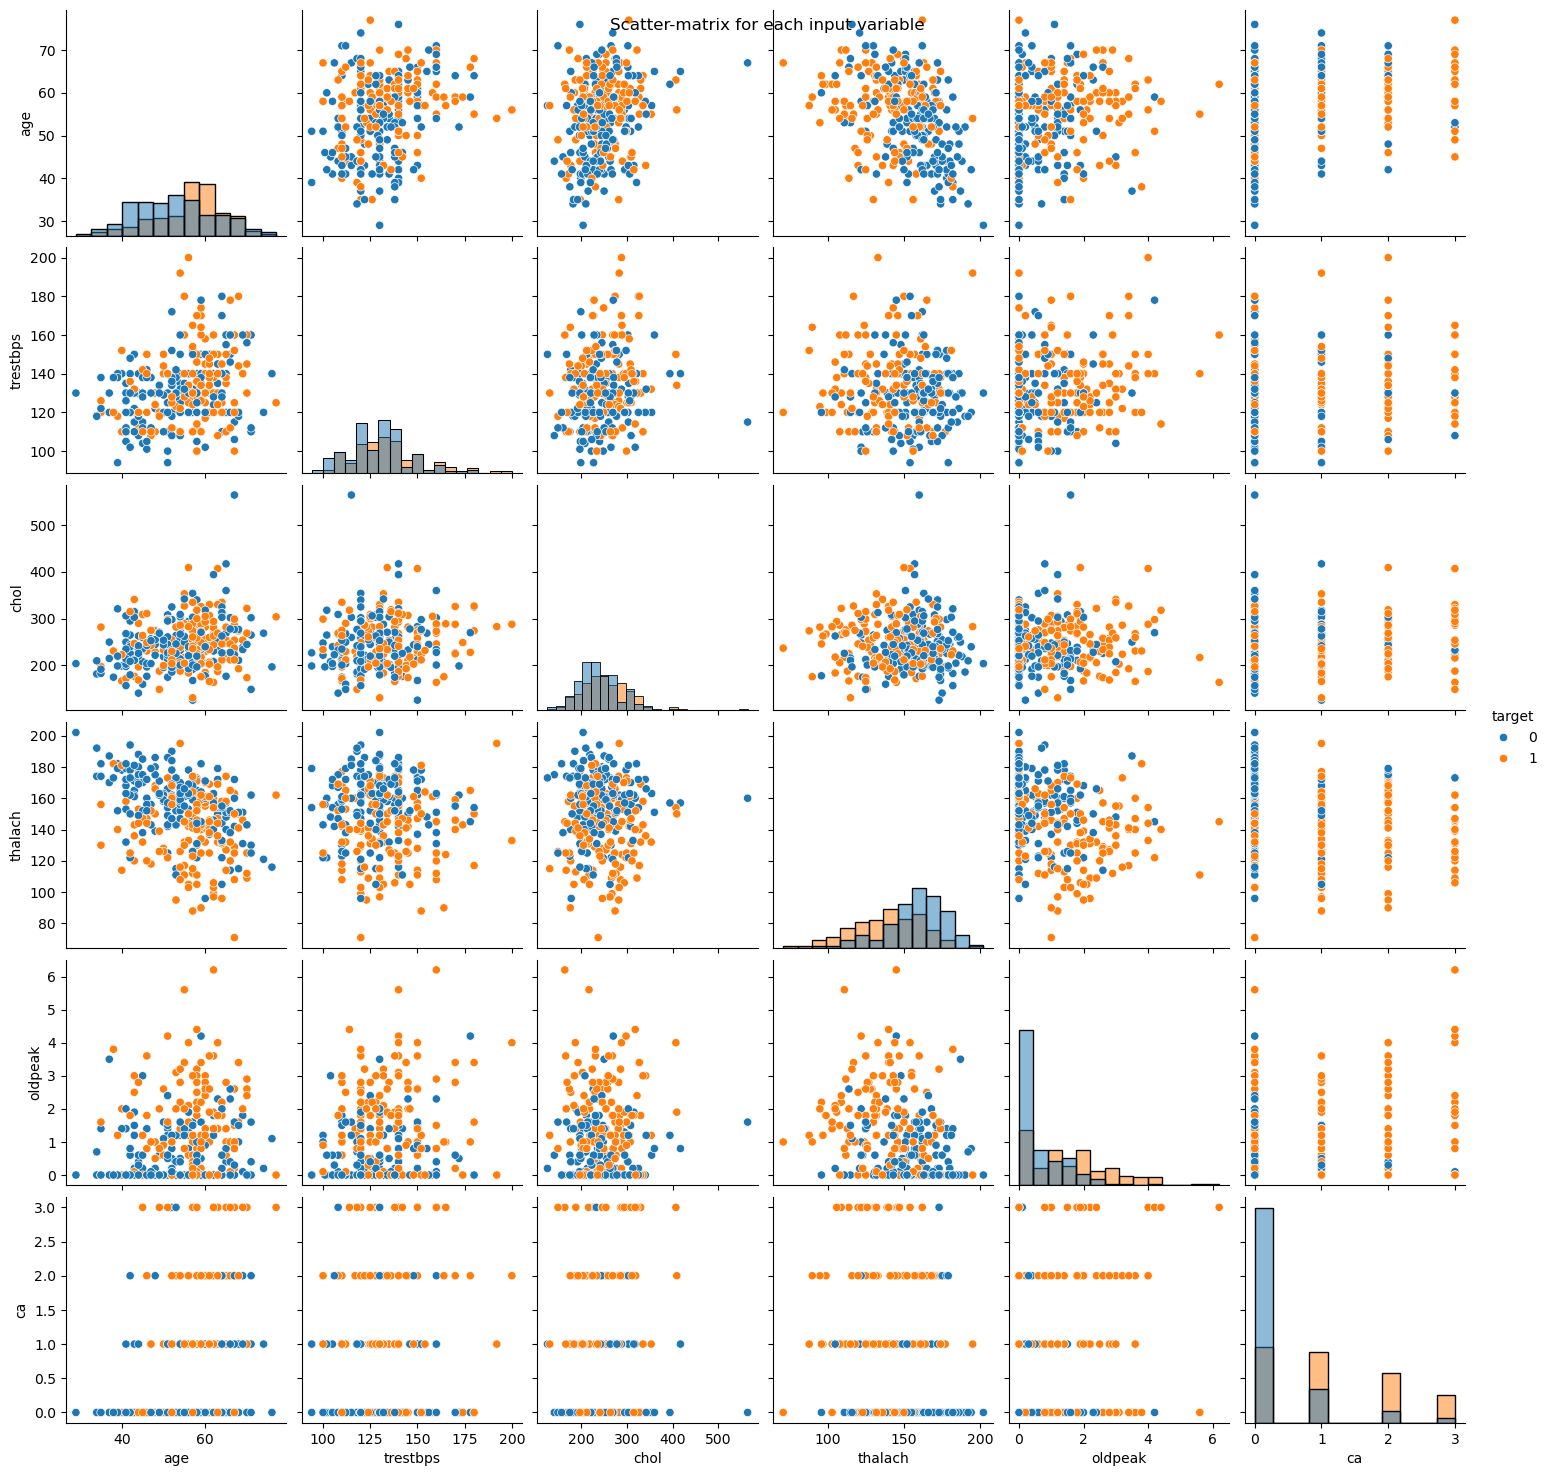

In [263]:
cols = df.columns  # Exclude the target variable
print(cols)
sns.pairplot(df, hue='target',diag_kind="hist",palette="tab10")
plt.suptitle('Scatter-matrix for each input variable')

Regarding the relationships between the variables:

* A moderate negative correlation is observed between age and maximum heart rate (as age increases, maximum heart rate decreases).
* No strong linear correlations were identified between most variables, indicating low redundancy.
* There is a relationship between oldpeak and thalach, whereby high oldpeak values tend to be associated with low thalach values. 

Regarding the target variable, the colours show that there is no clear separation between classes in pairs of individual variables. This suggests that:
* Discrimination between classes depends on the combination of multiple variables.
* The relationships may be non-linear, so more complex models will be necessary to capture these patterns.

In [264]:
X = df.drop('target', axis=1)
y = df['target']

# 2. Preprocessing

## 2.1 Encoding & Scaling

### Encoding
Although several variables were stored as numeric types, such as **(`sex`, `cp`[chest pain], `fbs`[fasting blood sugar], `restcg`, `examg`, `slope`, `thal`)**. These variable were therefore treated as categorical and encoded using-hot enconding to avoid introducing artificial ordinal relationship.

We used [get.dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) to convert categorical variable into dummy/indicator varianle

In [265]:
def encode_and_bind(original_dataframe, feature_to_encode):
    dummies = pd.get_dummies(original_dataframe[[feature_to_encode]])
    res = pd.concat([original_dataframe, dummies], axis=1)
    res = res.drop([feature_to_encode], axis=1)
    return(res)

In [266]:
# selects columns in the dataset that are of type category
cat_features = list(X.select_dtypes(include=['category']))

X_enc = copy.deepcopy(X)    # create a deep copy of X to ensure the original dataset be modified
for i in cat_features:
    X_enc = encode_and_bind(X_enc, i)

# Drop redundancy dummy variables to avoid multicollinearity  
X_enc.rename(columns = {
    'sex_1': 'is_male',
    'fbs_1': 'is_fbs',
    'exang_1': 'is_exang'
}, inplace=True)

X_enc.drop(columns=['sex_0', 'fbs_0', 'exang_0'], inplace=True)

X_enc.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    Int64  
 1   trestbps   303 non-null    Int64  
 2   chol       303 non-null    Int64  
 3   thalach    303 non-null    Int64  
 4   oldpeak    303 non-null    float64
 5   ca         303 non-null    Int64  
 6   is_male    303 non-null    bool   
 7   cp_1       303 non-null    bool   
 8   cp_2       303 non-null    bool   
 9   cp_3       303 non-null    bool   
 10  cp_4       303 non-null    bool   
 11  is_fbs     303 non-null    bool   
 12  restecg_0  303 non-null    bool   
 13  restecg_1  303 non-null    bool   
 14  restecg_2  303 non-null    bool   
 15  is_exang   303 non-null    bool   
 16  slope_1    303 non-null    bool   
 17  slope_2    303 non-null    bool   
 18  slope_3    303 non-null    bool   
 19  thal_3     303 non-null    bool   
 20  thal_6     303 non-nu

After encoding and drop redundant dummy variables the dataset contained 22 features, including both numerical variables and one-hot encoded categorical variable.

### Scaling
Standardization was applied using the `StandardScaler` from `sklearn`. This method subtract the mean and divides by standard deviation for each feature, resulting in variable with zero mean and unit variance

In [286]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enc)
X_scaled = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)

print("Means:", scaler.mean_)
print("Variances:", scaler.var_)

Means: [5.44389439e+01 1.31689769e+02 2.46693069e+02 1.49607261e+02
 1.03960396e+00 6.63366337e-01 6.79867987e-01 7.59075908e-02
 1.65016502e-01 2.83828383e-01 4.75247525e-01 1.48514851e-01
 4.98349835e-01 1.32013201e-02 4.88448845e-01 3.26732673e-01
 4.68646865e-01 4.62046205e-01 6.93069307e-02 5.54455446e-01
 5.94059406e-02 3.86138614e-01]
Variances: [8.14277903e+01 3.08728839e+02 2.67200150e+03 5.21538825e+02
 1.34364605e+00 8.70176127e-01 2.17647507e-01 7.01456284e-02
 1.37786056e-01 2.03269832e-01 2.49387315e-01 1.26458190e-01
 2.49997277e-01 1.30270453e-02 2.49866571e-01 2.19978433e-01
 2.49016981e-01 2.48559509e-01 6.45034801e-02 2.47034604e-01
 5.58768748e-02 2.37035585e-01]


The computer **means and variances** show substantial differences in the scale of the variables, with some features exhibiting significantly larger variability than others. This imbalance would bias distance-based methods such as PCA. Therefore, standardization was applied to normalize all features to a common scale, ensuring that no single variable dominates the analysis.

## 2.1 PCA Application

In [292]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    index=X_enc.index
)

pca_structure = pd.DataFrame(
    pca.components_.T, 
    columns=[f"PC{i+1}" for i in range(pca.n_components_)], # Asumiendo que X_scaled es un DataFrame con los nombres de las columnas
    index=X_scaled.columns
)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(explained)
print(cumulative)

[0.19745029 0.09699151 0.07723008 0.07289192 0.06510215 0.06129674
 0.05545268 0.05311961 0.04632777 0.04315579 0.04065856 0.036237
 0.03482927 0.03179965 0.02822375 0.02372235 0.0187227  0.01678818
 0.         0.         0.         0.        ]
[0.19745029 0.2944418  0.37167189 0.44456381 0.50966596 0.57096269
 0.62641537 0.67953498 0.72586275 0.76901854 0.8096771  0.8459141
 0.88074337 0.91254302 0.94076676 0.96448912 0.98321182 1.
 1.         1.         1.         1.        ]


### Explained Variance per Component:

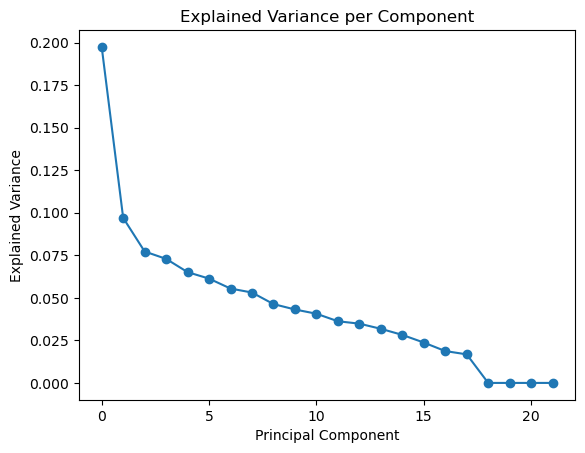

In [269]:
plt.plot(explained, marker='o')
plt.title("Explained Variance per Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.show()

We see that Sharp drop from PC1 to PC2, it means gradual decline, no very strong **elbow**.
The dataset does not have a very low intrinsic dimensionality.

### Cumulative Variance:

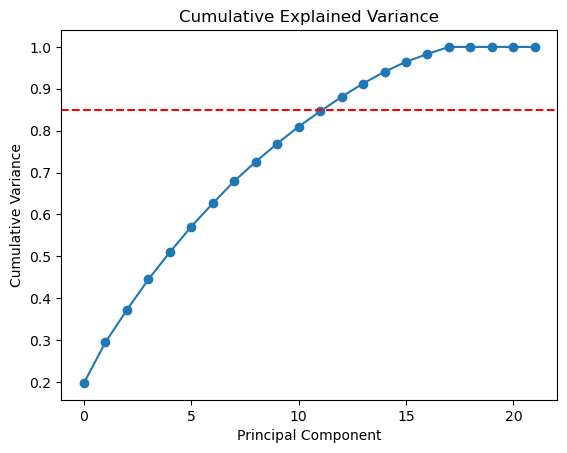

In [270]:
plt.plot(cumulative, marker='o')
plt.axhline(y=0.85, color='r', linestyle='--') # threshold at 85%
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.show()

The cumulative explained variance plot shows that approximately 12 principal components are required to retain at least 85% of the total variance in the dataset. This show that the dataset does not have a strong low-dimensional structure and that several components are needed to adequately capture the variability in the data
The absence of a clear elbow point further suggest that the data not exhibit strong redundancy and multiple dimensions are required to represent its structure.

### Select components that explain $\geq$ 85\% variance:

In [271]:
n_components = np.argmax(cumulative >= 0.85) + 1
print("Number of components (≥ 85% variance):", n_components)

Number of components (≥ 85% variance): 13


### 2D PCA Space:

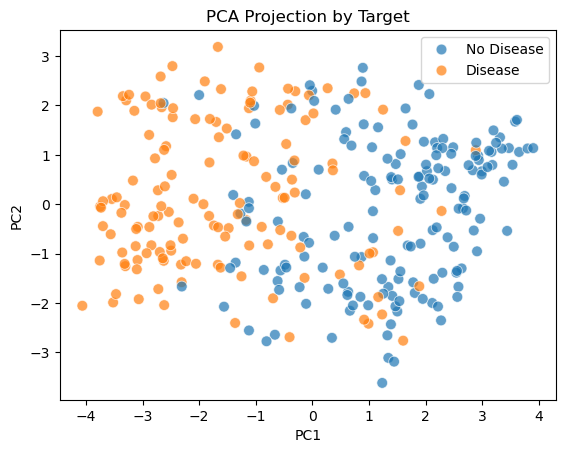

In [272]:
plt.figure()

# Plot each class separately
sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue = y.map({0: "No Disease", 1: "Disease"}),
    s = 60,
    alpha = 0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection by Target")
plt.legend()
plt.show()

- The PCA projection was colored according to the target variable, where `0` represents absence of heart disease and `1` represents presence of disease.
- The overlap between classes indicates that the first two principal components do not clearly separate the two groups.

## 2.2 Feature Selection

### Train - Test Split:

In [273]:
X_train, X_test, y_train, y_test, X_pca_train, X_pca_test = train_test_split(
    X_enc, y, X_pca,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Encode Target:
The `Target` is the diagnosis of heart disease, the original variable name is `num`.

In [274]:
# Define transform fro the target labels
label_encoder = LabelEncoder() # Fit and transform the training data
y_train_enc = label_encoder.fit_transform(y_train) # Transform the testing data
y_test_enc = label_encoder.transform(y_test)

### Rescale Features:
The scaled model must be fitted only with the training subset, and then applied in both subsets (train and test).

In [275]:
scaler_split = MinMaxScaler()
X_train_scaled = scaler_split.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = scaler_split.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

### Feature Selection Methods

#### k-Best (Univariate)
For **k-Best** we will use **ANOVA F-test** to select the most relevant features based on their statistical relationship with the target variable.

In [276]:
fs1 = SelectKBest(score_func=f_classif, k='all')

fs1 = fs1.fit(X_train_scaled, y_train_enc)
X_train_kbest = fs1.transform(X_train_scaled)
X_test_kbest = fs1.transform(X_test_scaled)

p-Value:

In [277]:
p_val = fs1.pvalues_
p_val = pd.Series(p_val, index=X_train_scaled.columns)
p_val.sort_values( inplace=True)
print(p_val)

thal_3       8.127647e-20
thal_7       6.418559e-18
cp_4         8.375688e-16
ca           2.400118e-13
is_exang     8.931125e-12
thalach      3.358391e-11
oldpeak      2.549157e-10
slope_1      3.331287e-09
slope_2      4.729094e-08
is_male      1.000435e-06
cp_3         2.076741e-05
cp_2         2.294848e-05
age          1.033443e-03
restecg_2    1.067988e-02
restecg_0    1.499515e-02
trestbps     3.435545e-02
cp_1         1.944099e-01
thal_6       2.277887e-01
chol         2.315500e-01
restecg_1    3.583861e-01
slope_3      3.905489e-01
is_fbs       4.773712e-01
dtype: float64


In [278]:
threshold = 0.001
idx = np.where(p_val<threshold)[0]
cols = list(p_val.index[idx])
X_kbest_pval = X_train_scaled[cols]

print("Number of features:", len(X_kbest_pval.columns))
print("Selected features:", X_kbest_pval.columns.tolist())
X_kbest_pval.head()

Number of features: 12
Selected features: ['thal_3', 'thal_7', 'cp_4', 'ca', 'is_exang', 'thalach', 'oldpeak', 'slope_1', 'slope_2', 'is_male', 'cp_3', 'cp_2']


,thal_3,thal_7,cp_4,ca,is_exang,thalach,oldpeak,slope_1,slope_2,is_male,cp_3,cp_2
180,0.0,1.0,1.0,0.000000,0.0,0.725191,0.080645,0.0,1.0,1.0,0.0,0.0
208,1.0,0.0,0.0,0.000000,0.0,0.641221,0.000000,1.0,0.0,1.0,0.0,1.0
167,1.0,0.0,0.0,0.333333,1.0,0.671756,0.000000,1.0,0.0,0.0,0.0,1.0
105,0.0,1.0,0.0,0.000000,0.0,0.648855,0.000000,1.0,0.0,1.0,0.0,1.0
297,0.0,1.0,1.0,0.000000,1.0,0.396947,0.032258,0.0,1.0,0.0,0.0,0.0


$\eta^2$ - F-Score:

Text(0.5, 1.0, 'Effect Size (η²) for Each Feature')

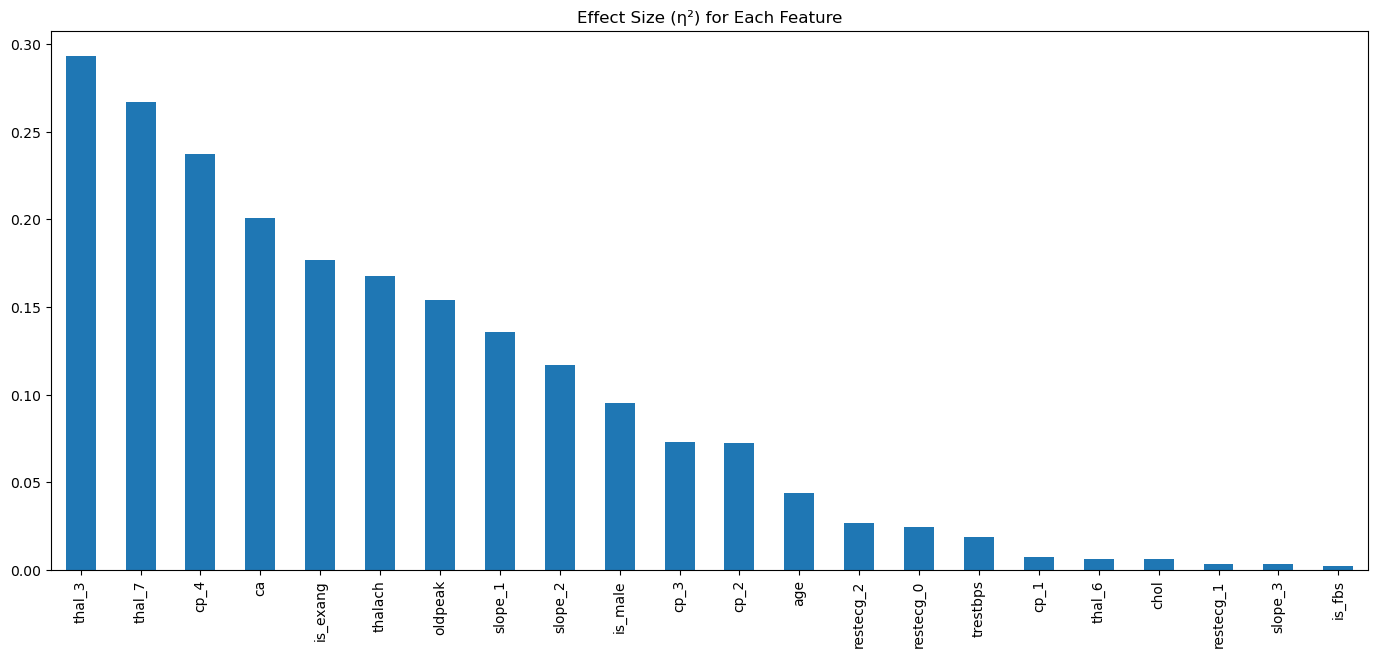

In [279]:
f_scores = fs1.scores_ # ANOVA test (f_classif)

n = X_train_scaled.shape[0] # Total number of samples
k = len(np.unique(y_train_enc)) # Number of groups/classes

df_between = k-1 # Degrees of freedom between
df_within = n-k # Degrees of freedom within
eta_squared = (f_scores*df_between) / ((f_scores*df_between) + df_within)

eta_squared = pd.Series(eta_squared, index=X_train.columns)
eta_squared.sort_values(ascending=False, inplace=True)
eta_squared.plot(kind='bar', figsize=(17,7))
plt.title("Effect Size (η²) for Each Feature")

- $0.01$: The feature explains 1% of variance (little effect)
- $0.06$: The feature explains 6% of variance (medium effect)
- $0.14$: The feature explains 14% of variance (high effect)

In [280]:
threshold = 0.14
idx = np.where(eta_squared>threshold)[0]
cols = list(eta_squared.index[idx])
X_kbest_eta = X_train_scaled[cols]

print("Number of features:", len(X_kbest_eta.columns))
print("Selected features:", X_kbest_eta.columns.tolist())
X_kbest_eta.head()

Number of features: 7
Selected features: ['thal_3', 'thal_7', 'cp_4', 'ca', 'is_exang', 'thalach', 'oldpeak']


,thal_3,thal_7,cp_4,ca,is_exang,thalach,oldpeak
180,0.0,1.0,1.0,0.000000,0.0,0.725191,0.080645
208,1.0,0.0,0.0,0.000000,0.0,0.641221,0.000000
167,1.0,0.0,0.0,0.333333,1.0,0.671756,0.000000
105,0.0,1.0,0.0,0.000000,0.0,0.648855,0.000000
297,0.0,1.0,1.0,0.000000,1.0,0.396947,0.032258


The selected features include both numerical variables (such as thalach, oldpeak, and ca) and encoded categorical variables (such as cp, exang, and thal). These variables are clinically meaningful and are known to be strong indicators of heart disease.

For instance, ST depression (oldpeak) and the number of major vessels (ca) are key diagnostic indicators, while maximum heart rate (thalach) reflects cardiovascular performance. The inclusion of categorical features such as chest pain type and exercise-induced angina further supports the model's ability to distinguish between patients with and without heart disease.

In [283]:
X_clustering = copy.deepcopy(X_kbest_eta)
X_pca_clustering = copy.deepcopy(X_pca_train)

#### Compare the selected feature subset with the components identified by PCA

In [312]:
pca_features = pca_structure[["PC1"]].sort_values(by="PC1", key=abs, ascending=False).index.tolist()
clustering_features = X_clustering.columns.tolist()
print(f"Order of important features (PCA):\n{pca_features[:len(clustering_features)]}\n")
print(f"Order of important features (k-Best):\n{clustering_features}\n")
print(f"Differences in feature importance:\n{list(set(pca_features[:len(clustering_features)]) - set(clustering_features))}\n")
print(f"Common features:\n{list(set(pca_features) & set(clustering_features))}\n")
print(f"k-Best {len(clustering_features)} selected features are in the top {max([pca_features.index(feature) for feature in clustering_features if feature in pca_features]) + 1} PCA features.")

Order of important features (PCA):
['slope_1', 'thal_3', 'oldpeak', 'thalach', 'cp_4', 'slope_2', 'thal_7']

Order of important features (k-Best):
['thal_3', 'thal_7', 'cp_4', 'ca', 'is_exang', 'thalach', 'oldpeak']

Differences in feature importance:
['slope_2', 'slope_1']

Common features:
['thal_7', 'cp_4', 'thalach', 'is_exang', 'thal_3', 'ca', 'oldpeak']

k-Best 7 selected features are in the top 9 PCA features.


# 3. K-Means Clustering

## 3.1 Elbow & Silhouette Plots

## 3.2 Final Model & Visualization

## 3.3 Cluster Characterisation

# 4. GMM Clustering

## 4.1 BIC / AIC Model Selection

## 4.2 Final Model & Visualization

## 4.3 Comparison with K-Means

# 5. Hierarchical Clustering

## 5.1 Dendogram

## 5.2 Cut & Cluster Visualization

## 5.3 Structural Comparison

# 6. Evaluation

## 6.1 ARI Scores

## 6.2 Confusion Matrix & Discussion